<a href="https://colab.research.google.com/github/Kelly23mosquera/ALGORTIMOS-INTELIGENCIA-ARTIFICIAL/blob/main/TP1/ALGORITMO_A_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nodo visitado: X
Nodo visitado: Z
Nodo visitado: M
Nodo visitado: I

Ruta encontrada: ['X', 'Z', 'M', 'I']
Costo total: 5


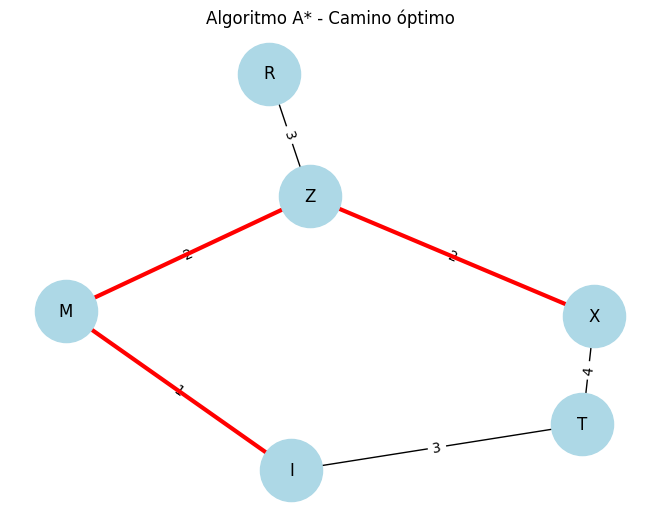

In [ ]:
import heapq  # Importa heapq para usar colas de prioridad
import networkx as nx  # Librería para trabajar con grafos
import matplotlib.pyplot as plt  # Librería para visualizar el grafo


# Función para reconstruir el camino desde el objetivo hasta el inicio
def reconstruir_camino(camino, inicio, objetivo):

    ruta = []  # Lista donde se guardará la ruta
    nodo = objetivo  # Empieza desde el nodo objetivo

    while nodo != inicio:  # Retrocede hasta llegar al nodo inicial
        ruta.append(nodo)  # Agrega el nodo a la ruta
        nodo = camino[nodo]  # Se mueve al nodo anterior

    ruta.append(inicio)  # Agrega el nodo inicial
    ruta.reverse()  # Invierte la lista para mostrar la ruta correcta

    return ruta  # Devuelve la ruta completa


# Algoritmo A*
def a_estrella(inicio, objetivo, grafo, heuristica):

    abiertos = []  # Lista de nodos por explorar
    heapq.heappush(abiertos, (heuristica[inicio], inicio))  # Inserta nodo inicial

    camino = {}  # Guarda el nodo anterior de cada nodo
    costo = {inicio: 0}  # Guarda el costo desde el inicio

    while abiertos:  # Mientras haya nodos por explorar

        prioridad, actual = heapq.heappop(abiertos)  # Extrae el nodo con menor prioridad

        print("Nodo visitado:", actual)  # Muestra nodo visitado

        if actual == objetivo:  # Si llega al objetivo

            ruta = reconstruir_camino(camino, inicio, objetivo)  # Reconstruye la ruta
            return ruta, costo[objetivo]  # Devuelve ruta y costo

        for vecino in grafo[actual]:  # Recorre vecinos

            nuevo_costo = costo[actual] + grafo[actual][vecino]  # Calcula g(n)

            if vecino not in costo or nuevo_costo < costo[vecino]:

                costo[vecino] = nuevo_costo  # Actualiza costo

                prioridad = nuevo_costo + heuristica[vecino]  # Calcula f(n)

                heapq.heappush(abiertos, (prioridad, vecino))  # Inserta vecino

                camino[vecino] = actual  # Guarda nodo anterior

    return None, float("inf")  # Si no hay solución


# Grafo usado en el problema
grafo = {
    'X': {'Z': 2, 'T': 4},
    'Z': {'R': 3, 'M': 2},
    'T': {'I': 3},
    'R': {},
    'M': {'I': 1},
    'I': {}
}


# Heurística estimada al objetivo
heuristica = {
    'X': 7,
    'Z': 4,
    'T': 3,
    'R': 2,
    'M': 1,
    'I': 0
}


# Ejecutar A*
ruta, costo_total = a_estrella('X', 'I', grafo, heuristica)

print("\nRuta encontrada:", ruta)
print("Costo total:", costo_total)


#  VISUALIZACIÓN DEL GRAFO

G = nx.Graph()  # Crear grafo para visualización

# Lista de aristas
edges = [
    ('X','Z',2),
    ('X','T',4),
    ('Z','R',3),
    ('Z','M',2),
    ('M','I',1),
    ('T','I',3)
]

# Agregar aristas al grafo
for u, v, w in edges:
    G.add_edge(u, v, weight=w)

# Crear aristas del camino óptimo
edges_camino = list(zip(ruta, ruta[1:]))

# Posición de nodos
pos = nx.spring_layout(G)

# Dibujar grafo
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color='lightblue',
    node_size=2000
)

# Dibujar pesos
labels = nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G,pos,edge_labels=labels)

# Resaltar camino óptimo
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=edges_camino,
    edge_color='red',
    width=3
)

plt.title("Algoritmo A* - Camino óptimo")
plt.show()